In [1]:
import os
import pandas as pd
import glob

# 대상 폴더 경로
folder_path = "/workspace/gits/KURE/eval/results"

# 모든 하위 폴더까지 포함하여 .json 파일 경로 찾기
json_files = glob.glob(os.path.join(folder_path, "**", "*.json"), recursive=True)
except_files = ['model_meta.json', 'MultiLongDocRetrieval.json']
json_files = [file for file in json_files if os.path.basename(file) not in except_files]



In [2]:
df_list = []
for file in json_files:
    try:
        df = pd.read_json(file, lines=False)

        # 모델 이름을 경로에서 추출 (예: /.../results/***여기***/*.json)
        # 아래 코드는 `results` 바로 하위 폴더명을 모델명으로 추출함
        rel_path = os.path.relpath(file, folder_path)
        model_name = rel_path.split('/')[:-3]

        df['model'] = '/'.join(model_name)
        df_list.append(df)
    except Exception as e:
        print(f"❗️{file} 파일 읽기 실패: {e}")

# 하나의 DataFrame으로 병합
final_df = pd.concat(df_list, ignore_index=True)
final_df

,dataset_revision,task_name,mteb_version,scores,evaluation_time,kg_co2_emissions,model
0,c99d599f0a6ab9b85b065da6f9d94f9cf731679f,XPQARetrieval,1.36.34,"[{'ndcg_at_1': 0.16820000000000002, 'ndcg_at_3...",2.493143,NaN,sentence-transformers/paraphrase-multilingual-...
1,main,PublicHealthQA,1.36.34,"[{'ndcg_at_1': 0.53247, 'ndcg_at_3': 0.5963200...",0.087147,NaN,sentence-transformers/paraphrase-multilingual-...
2,main,MIRACLRetrieval,1.36.34,"[{'ndcg_at_1': 0.23005000000000003, 'ndcg_at_3...",347.257988,NaN,sentence-transformers/paraphrase-multilingual-...
3,d243889a3eb6654029dbd7e7f9319ae31d58f97c,Ko-StrategyQA,1.36.34,"[{'ndcg_at_1': 0.38007, 'ndcg_at_3': 0.38395, ...",3.714900,NaN,sentence-transformers/paraphrase-multilingual-...
4,75b399394a9803252cfec289d103de462763db7c,BelebeleRetrieval,1.36.34,"[{'ndcg_at_1': 0.5977800000000001, 'ndcg_at_3'...",2.368679,NaN,sentence-transformers/paraphrase-multilingual-...
...,...,...,...,...,...,...,...
615,fc24a3ce8f09746410daee3d5cd823ff7a0675b7,MrTidyRetrieval,1.19.4,"[{'hf_subset': 'korean', 'languages': ['kor-Ko...",15034.357435,NaN,BAAI/bge-m3
616,main,MIRACLRetrieval,1.19.4,"[{'hf_subset': 'ko', 'languages': ['kor-Kore']...",25134.011864,NaN,BAAI/bge-m3
617,d243889a3eb6654029dbd7e7f9319ae31d58f97c,Ko-StrategyQA,1.19.4,"[{'hf_subset': 'default', 'languages': ['kor-H...",185.896979,NaN,BAAI/bge-m3
618,75b399394a9803252cfec289d103de462763db7c,BelebeleRetrieval,1.19.4,"[{'hf_subset': 'kor_Hang-kor_Hang', 'languages...",42.116354,NaN,BAAI/bge-m3


In [3]:
final_df['scores'].apply(lambda x: len(x))

0      3
1      1
2      1
3      1
4      3
      ..
615    1
616    1
617    1
618    3
619    1
Name: scores, Length: 620, dtype: int64

In [4]:
final_df['scores'] = final_df['scores'].apply(lambda x : x[0]['ndcg_at_10'] if (x[0]['hf_subset'] == 'kor-kor') or (len(x) == 1) or (x[0]['hf_subset'] == 'kor_Hang-kor_Hang') else x)
final_df

,dataset_revision,task_name,mteb_version,scores,evaluation_time,kg_co2_emissions,model
0,c99d599f0a6ab9b85b065da6f9d94f9cf731679f,XPQARetrieval,1.36.34,0.21345,2.493143,NaN,sentence-transformers/paraphrase-multilingual-...
1,main,PublicHealthQA,1.36.34,0.67409,0.087147,NaN,sentence-transformers/paraphrase-multilingual-...
2,main,MIRACLRetrieval,1.36.34,0.25676,347.257988,NaN,sentence-transformers/paraphrase-multilingual-...
3,d243889a3eb6654029dbd7e7f9319ae31d58f97c,Ko-StrategyQA,1.36.34,0.45903,3.714900,NaN,sentence-transformers/paraphrase-multilingual-...
4,75b399394a9803252cfec289d103de462763db7c,BelebeleRetrieval,1.36.34,0.71491,2.368679,NaN,sentence-transformers/paraphrase-multilingual-...
...,...,...,...,...,...,...,...
615,fc24a3ce8f09746410daee3d5cd823ff7a0675b7,MrTidyRetrieval,1.19.4,0.64708,15034.357435,NaN,BAAI/bge-m3
616,main,MIRACLRetrieval,1.19.4,0.70146,25134.011864,NaN,BAAI/bge-m3
617,d243889a3eb6654029dbd7e7f9319ae31d58f97c,Ko-StrategyQA,1.19.4,0.79405,185.896979,NaN,BAAI/bge-m3
618,75b399394a9803252cfec289d103de462763db7c,BelebeleRetrieval,1.19.4,0.93164,42.116354,NaN,BAAI/bge-m3


In [5]:
final_df.drop(columns=['dataset_revision', 'mteb_version','evaluation_time','kg_co2_emissions'], inplace=True)
final_df['scores'] = final_df['scores'].apply(lambda x: float(x))

In [6]:
final_df = final_df.groupby('model').agg({'scores':'mean'}).reset_index().sort_values(by='scores', ascending=False)
final_df

,model,scores
3,dragonkue/BGE-m3-ko,0.729993
11,nlpai-lab/KURE-v1,0.727739
0,BAAI/bge-m3,0.724169
2,Snowflake/snowflake-arctic-embed-l-v2.0,0.724104
8,intfloat/multilingual-e5-large,0.721607
...,...,...
5,ibm-granite/granite-embedding-278m-multilingual,0.641935
4,ibm-granite/granite-embedding-107m-multilingual,0.625862
15,workspace/script/models/me5-small-MNR/checkpoi...,0.625713
14,workspace/script/models/me5-small-MNR/checkpoi...,0.622144


In [7]:
final_df['model'] = final_df['model'].apply(lambda x : '/'.join(x.split('/')[3:]) if x.split('/')[0]=='workspace' else x)
final_df

,model,scores
3,dragonkue/BGE-m3-ko,0.729993
11,nlpai-lab/KURE-v1,0.727739
0,BAAI/bge-m3,0.724169
2,Snowflake/snowflake-arctic-embed-l-v2.0,0.724104
8,intfloat/multilingual-e5-large,0.721607
...,...,...
5,ibm-granite/granite-embedding-278m-multilingual,0.641935
4,ibm-granite/granite-embedding-107m-multilingual,0.625862
15,me5-small-MNR/checkpoint-204,0.625713
14,me5-small-MNR/checkpoint-102,0.622144


In [8]:
# 중복 제거용 모델 이름 정제
def normalize_model_name(model_name):
    parts = model_name.split('/')
    last = parts[-1]
    if 'checkpoint' in last or 'final' in last:
        return '/'.join(parts[:-1])
    return model_name

# 모델명 정제 적용
final_df['model'] = final_df['model'].apply(normalize_model_name)

# scores 기준으로 높은 것만 남기기
final_df = final_df.sort_values("scores", ascending=False)
final_df = final_df.drop_duplicates(subset=["model"], keep="first")
final_df


,model,scores
3,dragonkue/BGE-m3-ko,0.729993
11,nlpai-lab/KURE-v1,0.727739
0,BAAI/bge-m3,0.724169
2,Snowflake/snowflake-arctic-embed-l-v2.0,0.724104
8,intfloat/multilingual-e5-large,0.721607
12,nlpai-lab/KoE5,0.711356
1,BAAI/bge-multilingual-gemma2,0.704274
9,intfloat/multilingual-e5-large-instruct,0.698370
7,intfloat/multilingual-e5-base,0.689429
28,me5-small-guide-arctic-absolute-0.1-wsd-continue,0.688849


In [9]:
final_df = final_df[~final_df['model'].isin(['intfloat/multilingual-e5-large-instruct', 'me5-small-guide-arctic-absolute-0.1-wsd-continue',
                                             'dragonkue/BGE-m3-ko','nlpai-lab/KURE-v1','nlpai-lab/KoE5','BAAI/bge-multilingual-gemma2','intfloat/e5-mistral-7b-instruct','prev/me5-small-guide-arctic-no-margin-bs12000'])]
final_df

,model,scores
0,BAAI/bge-m3,0.724169
2,Snowflake/snowflake-arctic-embed-l-v2.0,0.724104
8,intfloat/multilingual-e5-large,0.721607
7,intfloat/multilingual-e5-base,0.689429
21,me5-small-guide-arctic-absolute-0.1-v2-continue,0.688393
72,me5-small-guide-arctic-v3-absolute-0.08,0.687156
33,me5-small-guide-arctic-absolute-0.1-wsd,0.686614
30,me5-small-guide-arctic-absolute-0.1-wsd-not-nodup,0.686093
37,me5-small-guide-arctic-absolute-0.1,0.685983
16,me5-small-guide-arctic-absolute-0.05,0.685731


In [10]:
final_df['model'].to_list()

['BAAI/bge-m3',
 'Snowflake/snowflake-arctic-embed-l-v2.0',
 'intfloat/multilingual-e5-large',
 'intfloat/multilingual-e5-base',
 'me5-small-guide-arctic-absolute-0.1-v2-continue',
 'me5-small-guide-arctic-v3-absolute-0.08',
 'me5-small-guide-arctic-absolute-0.1-wsd',
 'me5-small-guide-arctic-absolute-0.1-wsd-not-nodup',
 'me5-small-guide-arctic-absolute-0.1',
 'me5-small-guide-arctic-absolute-0.05',
 'me5-small-guide-arctic-v2-absolute-0.08',
 'me5-small-guide-arctic-absolute-0.1-v2',
 'me5-small-guide-arctic-percentage-0.9',
 'me5-small-guide-arctic-v4-absolute-0.08',
 'me5-small-guide-arctic-percentage-0.85',
 'me5-small-guide-arctic-percentage-0.95',
 'me5-small-guide-arctic-v5-absolute-0.08',
 'me5-small-guide-arctic-v2-absolute-0.1',
 'me5-small-guide-arctic-no-table-absolute-0.1',
 'me5-small-guide-arctic-absolute-0.15',
 'me5-small-guide-arctic-no-margin',
 'me5-small-guide-arctic-absolute-large-batchsize_no-clustering',
 'me5-small-guide-arctic-no-margin-lr3e-4',
 'me5-small-g

In [11]:
# 모델 크기 부여 함수 정의
def get_model_size(model_name):
    if model_name in [
        'BAAI/bge-m3',
        'Snowflake/snowflake-arctic-embed-l-v2.0',
        'intfloat/multilingual-e5-large',
        'nlpai-lab/KoE5',
        'intfloat/multilingual-e5-large-instruct',
    ]:
        return 560
    elif model_name.startswith('me5') or model_name in ['intfloat/multilingual-e5-small']:
        return 128
    elif model_name in ['intfloat/multilingual-e5-base']:   
        return 256
    elif '278m' in model_name:
        return 278
    elif '107m' in model_name: 
        return 107
    else:
        return 120

# size 컬럼 추가
final_df['size'] = final_df['model'].apply(get_model_size)
final_df

/tmp/ipykernel_9833/4225541825.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['size'] = final_df['model'].apply(get_model_size)


,model,scores,size
0,BAAI/bge-m3,0.724169,560
2,Snowflake/snowflake-arctic-embed-l-v2.0,0.724104,560
8,intfloat/multilingual-e5-large,0.721607,560
7,intfloat/multilingual-e5-base,0.689429,256
21,me5-small-guide-arctic-absolute-0.1-v2-continue,0.688393,128
72,me5-small-guide-arctic-v3-absolute-0.08,0.687156,128
33,me5-small-guide-arctic-absolute-0.1-wsd,0.686614,128
30,me5-small-guide-arctic-absolute-0.1-wsd-not-nodup,0.686093,128
37,me5-small-guide-arctic-absolute-0.1,0.685983,128
16,me5-small-guide-arctic-absolute-0.05,0.685731,128


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df= final_df.iloc[:-1].copy()

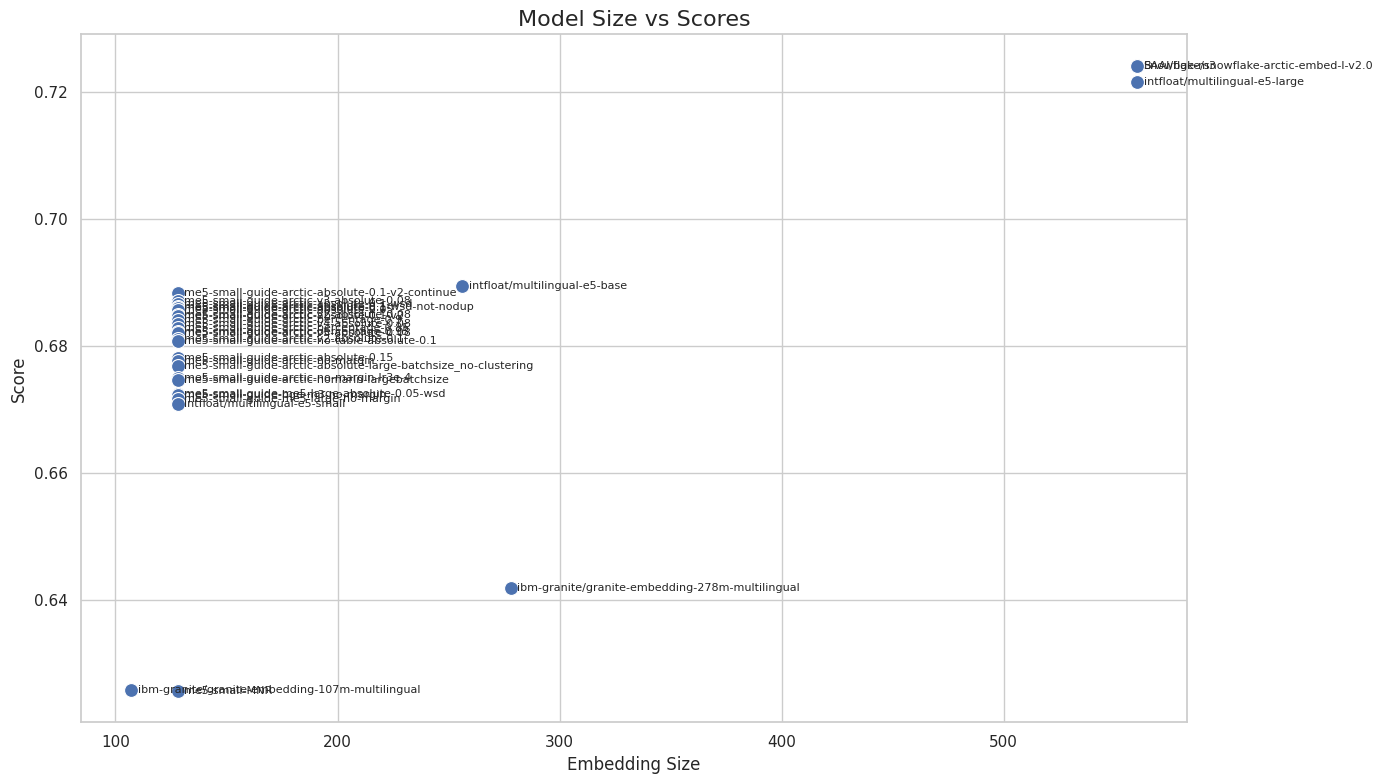

In [13]:
import seaborn as sns

# 시각적 개선된 스타일 설정
plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")

# 산점도 그리기
ax = sns.scatterplot(data=df, x="size", y="scores", s=100)

# 모델명 레이블 추가
for i in range(len(df)):
    x = df.iloc[i]['size']
    y = df.iloc[i]['scores']
    label = df.iloc[i]['model']
    if pd.notnull(x) and pd.notnull(y):
        ax.text(x + 3, y, label, fontsize=8, verticalalignment='center')

plt.title("Model Size vs Scores", fontsize=16)
plt.xlabel("Embedding Size", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.tight_layout()
plt.show()


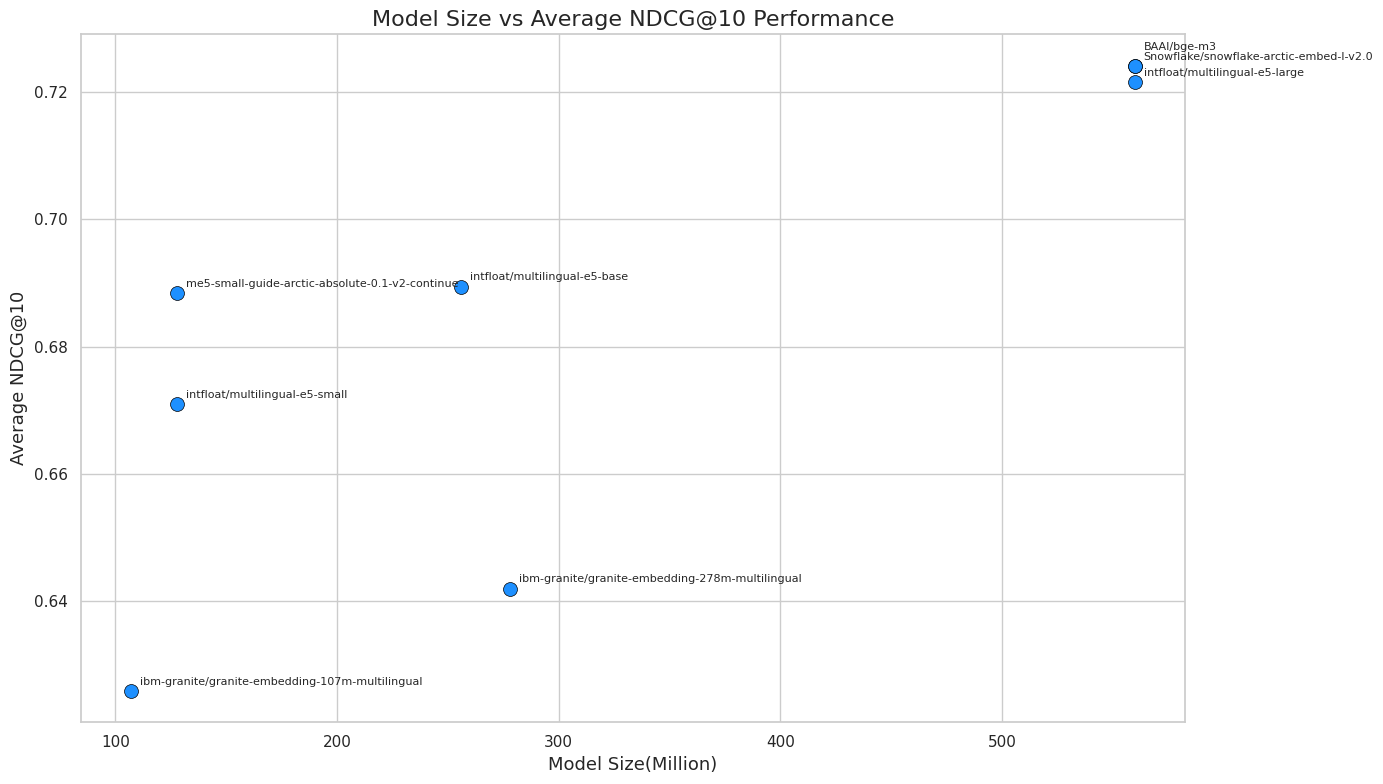

In [14]:
# 'me5'로 시작하는 모델 중 score가 가장 높은 하나만 남기고 제거
me5_mask = df['model'].str.startswith('me5')
df_me5 = df[me5_mask]
df_non_me5 = df[~me5_mask]

# scores 기준 최대 모델만 남기기
df_me5_top1 = df_me5.loc[df_me5['scores'].idxmax()]

# 최종 df로 병합
df_filtered = pd.concat([df_non_me5, pd.DataFrame([df_me5_top1])], ignore_index=True)

import seaborn as sns
import matplotlib.pyplot as plt

# 시각화 스타일
plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")


# 산점도 그리기
scatter = sns.scatterplot(data=df_filtered, x='size', y='scores', s=100, color='dodgerblue', edgecolor='black', linewidth=0.5)

# 텍스트 겹치지 않게 배치
for i in range(len(df_filtered)):
    x = df_filtered.iloc[i]['size']
    y = df_filtered.iloc[i]['scores']
    label = df_filtered.iloc[i]['model']
    if pd.notnull(x) and pd.notnull(y):
        offset = (12 if 'BAAI' in label else 5)
        plt.text(x + 4, y + offset * 0.0002, label, fontsize=8)

# 축 및 제목 스타일링
plt.title("Model Size vs Average NDCG@10 Performance", fontsize=16)
plt.xlabel("Model Size(Million)", fontsize=13)
plt.ylabel("Average NDCG@10", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()
